# Lab 2 — Digital Image Fundamentals
**Course:** ARTI407 – Image Processing  
**College of Computer Science and Information Technology**  
**Imam Abdulrahman Bin Faisal University**

This notebook covers the lab manual:
1. **Sampling and Quantization**
2. **Arithmetic Operations** (add, subtract, add constant)
3. **Set / Logical Operations** (union, intersection, difference, symmetric difference)
4. **Practical Tasks**

> **Note on images:** The lab references `lena_gray_256.tif`, `cameraman.tif`, `A.png`, `B.png`. Since those files aren't bundled with the notebook, this notebook uses built-in `skimage` images so every cell runs out of the box. To use your own image, just replace the loading line.

## Setup

In [1]:
import cv2 #computer vision lib, deal with it as arrays
import numpy as np
from PIL import Image #deal with images
from skimage import data
import matplotlib.pyplot as plt

%matplotlib inline

---
## Section 1 — Image Sampling and Quantization

- **Sampling** = how many pixels we keep (spatial resolution).
- **Quantization** = how many gray levels we keep (intensity resolution).

In [16]:
def sample_image(image, factor):
    """Downsamples the image by the given factor."""
    height, width = image.shape[:2] #has 3 attributes h,w,c
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST) #inter_nearest to choose the new image pixels
    return sampled_image


def quantize_image(image, levels): #Darken the image
    """Reduces the number of grayscale levels in the image."""
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)  
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image


def plot_images(original, sampled, quantized):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1), plt.imshow(original, cmap='gray')
    plt.title('Original Image'), plt.axis('off')
    plt.subplot(1, 3, 2), plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image'), plt.axis('off')
    plt.subplot(1, 3, 3), plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image'), plt.axis('off')
    plt.show()

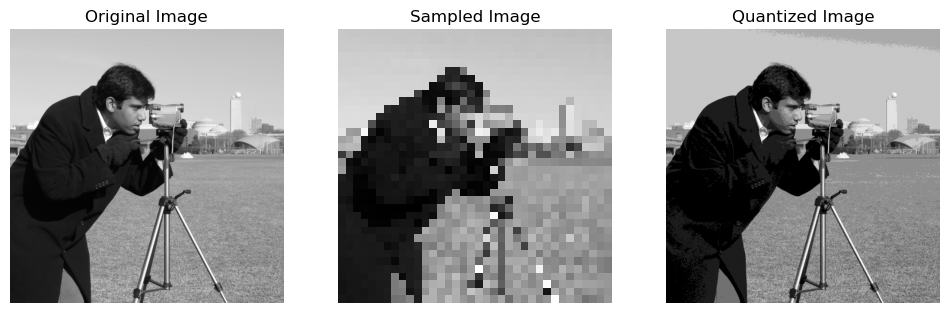

In [17]:
original_image = data.camera()

sampling_factor = 14
quantization_levels = 9

sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

plot_images(original_image, sampled_image, quantized_image)

---
## Section 2 — Arithmetic Operations

Add two images by converting them to numpy arrays and adding element-wise.

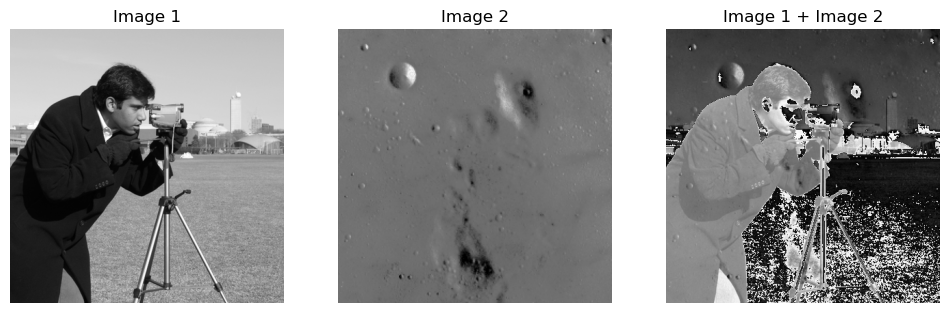

In [18]:
# 1. object images and we bring the images we will use (PIL arrays)
img1 = Image.fromarray(data.camera())
img2 = Image.fromarray(data.moon())

# 2. convert to image to use resize
new_size = (400, 400)
img1 = img1.resize(new_size, Image.Resampling.LANCZOS)      #do calculations then select the nearest pixels for the new image
img2 = img2.resize(new_size, Image.Resampling.LANCZOS)

# 3. convert the images to arrays so we can add them
im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

# 4. do addtion then convert back to images so we can show it
addition = im1arr + im2arr
result_image = Image.fromarray(addition)

# 5. plot the image
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img1, cmap='gray'), plt.title('Image 1'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img2, cmap='gray'), plt.title('Image 2'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image, cmap='gray'), plt.title('Image 1 + Image 2'), plt.axis('off')
plt.show()

---
## Section 3 — Set / Logical Operations

Pixel-wise bitwise operations on two images. Lab demo: **union (OR)**.

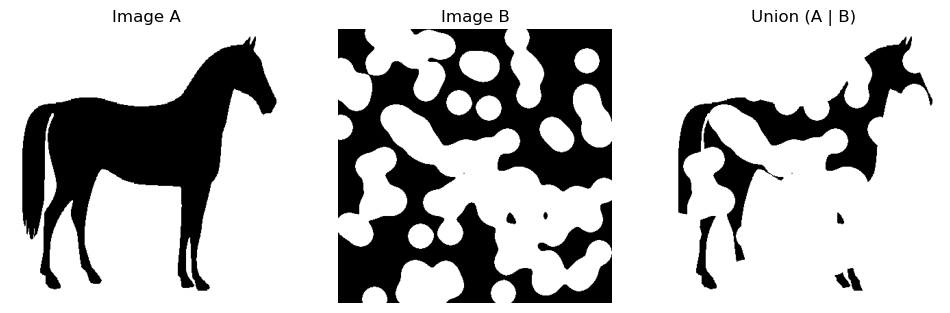

In [19]:
img3 = Image.fromarray(data.horse())
img4 = Image.fromarray(data.binary_blobs(length=400))

img3 = img3.resize(new_size, Image.Resampling.LANCZOS)
img4 = img4.resize(new_size, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

union = im4arr | im3arr
result_image_2 = Image.fromarray(union)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(img3, cmap='gray'), plt.title('Image A'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(img4, cmap='gray'), plt.title('Image B'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result_image_2, cmap='gray'), plt.title('Union (A | B)'), plt.axis('off')
plt.show()

---
# Practical Tasks

## Task 1 — Change sampling and quantization parameters and observe the effects

Try multiple values of the sampling factor and the number of quantization levels to see how each affects the image.

### 1a) Effect of sampling factor (spatial resolution)

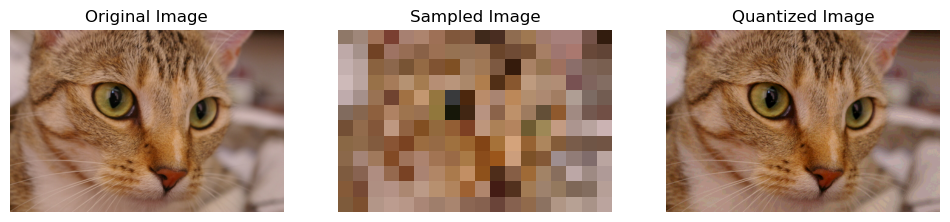

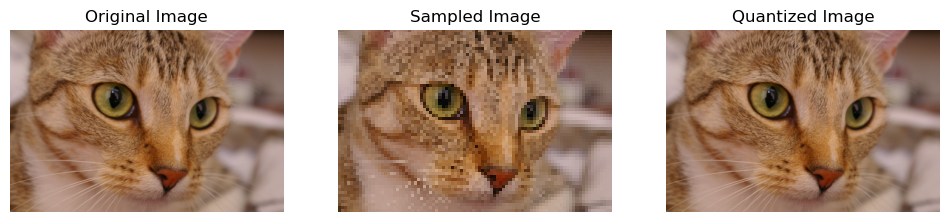

In [66]:
cat_img = data.cat()

sampling_factor = 25
quantization_levels = 20
sampled_image = sample_image(cat_img, sampling_factor)
quantized_image = quantize_image(cat_img, quantization_levels)
plot_images(cat_img, sampled_image, quantized_image)

sampling_factor = 5
quantization_levels = 100
sampled_image = sample_image(cat_img, sampling_factor)
quantized_image = quantize_image(cat_img, quantization_levels)
plot_images(cat_img, sampled_image, quantized_image)

### 1b) Effect of quantization levels (intensity resolution)

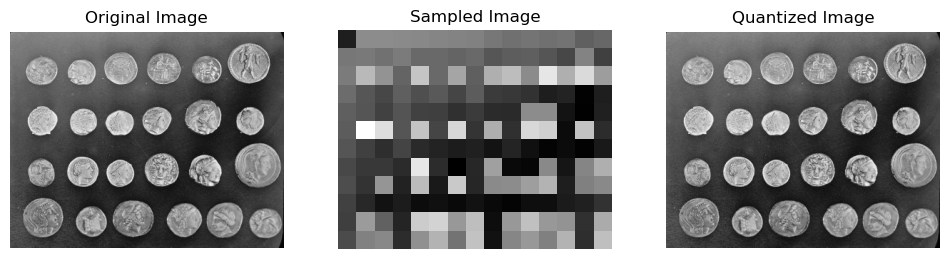

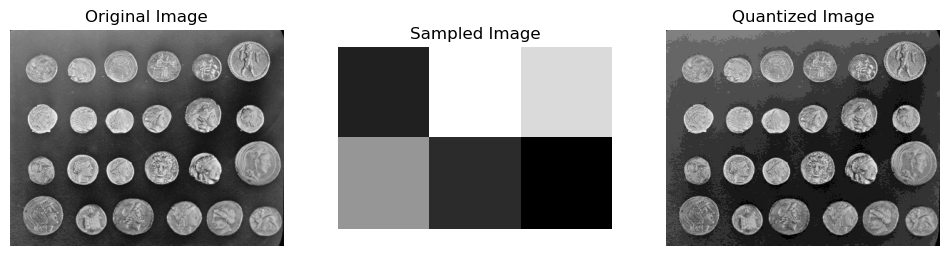

In [67]:
coins_img = data.coins()

sampling_factor = 25
quantization_levels = 50
sampled_image = sample_image(coins_img, sampling_factor)
quantized_image = quantize_image(coins_img, quantization_levels)
plot_images(coins_img, sampled_image, quantized_image)

sampling_factor = 110
quantization_levels = 10
sampled_image = sample_image(coins_img, sampling_factor)
quantized_image = quantize_image(coins_img, quantization_levels)
plot_images(coins_img, sampled_image, quantized_image)

---
## Task 2 — Image Arithmetic and Set Operations

Required operations:
1. Subtract two images and display the result
2. Add one image with a constant value 175
3. Set difference on two grayscale images
4. Symmetric difference on two grayscale images
5. Intersection on two grayscale images

In [87]:
# The used images

cat_img = Image.fromarray(data.cat()).convert('L') # convert colored image into grayscale image to do the operations
camera_img = Image.fromarray(data.camera())
coins_img = Image.fromarray(data.coins())
horse_img = Image.fromarray(data.horse())
blobs_img = Image.fromarray(data.binary_blobs())

# Images size
new_size = (400, 400)

### 2a) Subtract two images

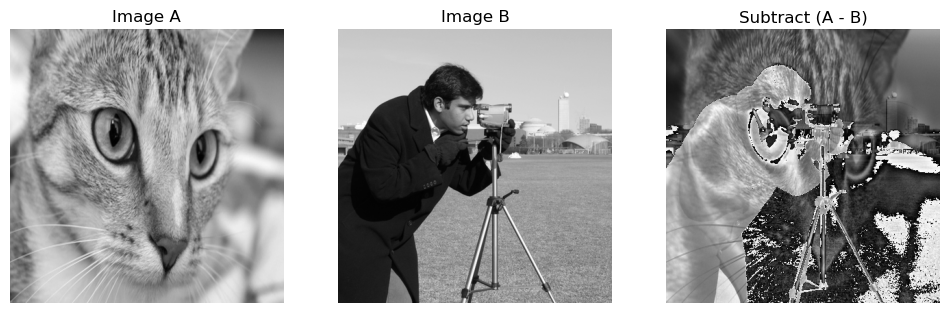

In [88]:
# Step 1
cat_img = cat_img.resize(new_size, Image.Resampling.LANCZOS)
camera_img  = camera_img .resize(new_size, Image.Resampling.LANCZOS)

# Step 2
arr_cat = np.asarray(cat_img)
arr_camera = np.asarray(camera_img)

# Step 3
sub = arr_camera.astype(np.int8) - arr_cat.astype(np.int8)
result = Image.fromarray(sub)

# Step 4
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(cat_img, cmap='gray'), plt.title('Image A'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(camera_img, cmap='gray'), plt.title('Image B'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result, cmap='gray'), plt.title('Subtract (A - B)'), plt.axis('off')
plt.show()

### 2b) Add image with constant value 175

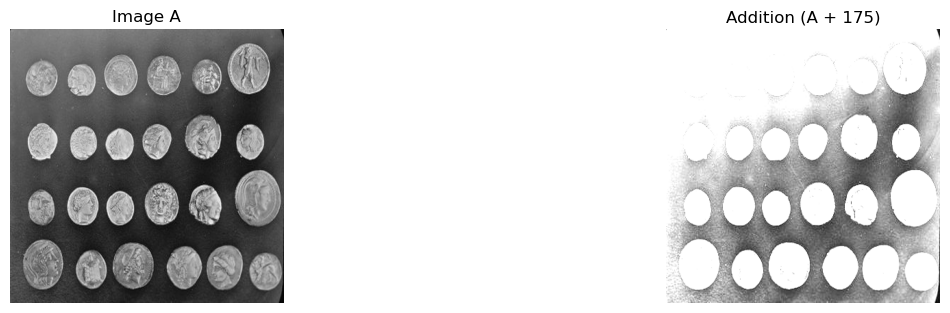

In [90]:
# Step 1
coins_img = coins_img.resize(new_size, Image.Resampling.LANCZOS)

# Step 2
arr_coins = np.asarray(coins_img)

# Step 3
const_sum = np.clip(arr_coins.astype(np.int16) + 175, 0, 255).astype(np.uint8)
result = Image.fromarray(const_sum)

# Step 4
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(coins_img, cmap='gray'), plt.title('Image A'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result, cmap='gray'), plt.title('Addition (A + 175)'), plt.axis('off')
plt.show()

### 2c-2e) Set operations on grayscale images

| Operation | Bitwise formula | Meaning |
|---|---|---|
| **Intersection** | `A & B` | bits set in both |
| **Set difference** | `A & ~B` (A − B) | bits in A but not in B |
| **Symmetric difference** | `A ^ B` | bits in A or B but not both |
| **Union** (extra) | `A \| B` | bits in either |

### 2c) Set difference on two grayscale images

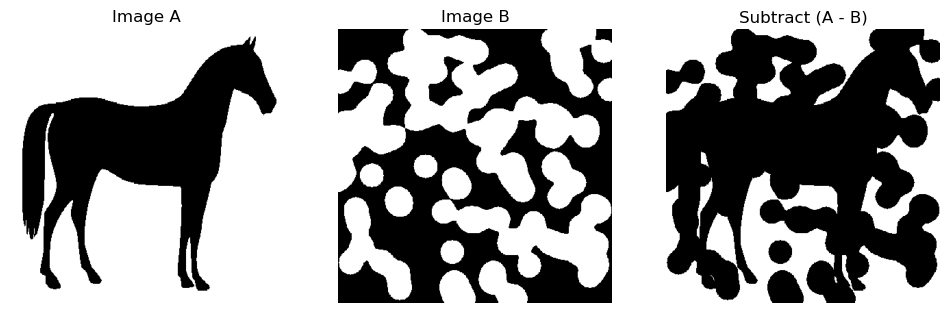

In [91]:
# Step 1
horse_img = horse_img.resize(new_size, Image.Resampling.LANCZOS)
blobs_img = blobs_img.resize(new_size, Image.Resampling.LANCZOS)

# Step 2
arr_horse = np.asarray(horse_img)
arr_blobs = np.asarray(blobs_img)

# Step 3
sub = arr_horse & ~arr_blobs 
result = Image.fromarray(sub)

# Step 4
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(horse_img, cmap='gray'), plt.title('Image A'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(blobs_img, cmap='gray'), plt.title('Image B'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result, cmap='gray'), plt.title('Subtract (A - B)'), plt.axis('off')
plt.show()

### 2d) Symmetric difference on two grayscale images

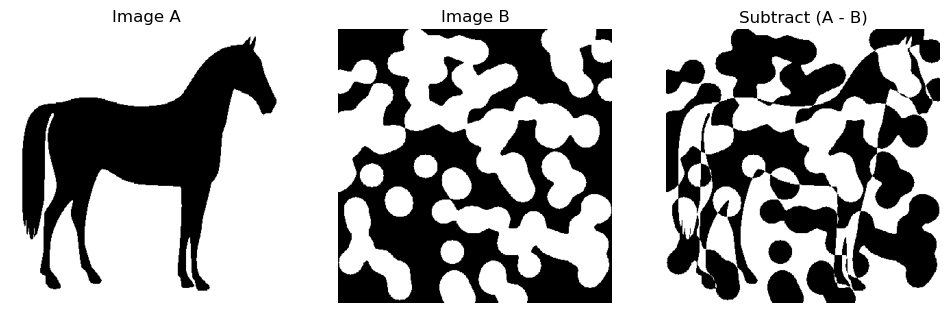

In [93]:
# Step 1
horse_img = horse_img.resize(new_size, Image.Resampling.LANCZOS)
blobs_img = blobs_img.resize(new_size, Image.Resampling.LANCZOS)

# Step 2
arr_horse = np.asarray(horse_img)
arr_blobs = np.asarray(blobs_img)

# Step 3
sub = arr_horse ^ arr_blobs
result = Image.fromarray(sub)

# Step 4
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(horse_img, cmap='gray'), plt.title('Image A'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(blobs_img, cmap='gray'), plt.title('Image B'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result, cmap='gray'), plt.title('Subtract (A - B)'), plt.axis('off')
plt.show()

### 2e) Intersection on two grayscale images

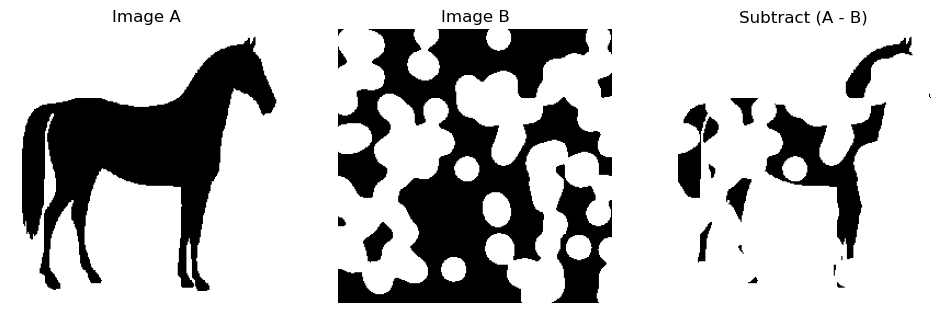

In [85]:
# Step 1
horse_img = horse_img.resize(new_size, Image.Resampling.LANCZOS)
blobs_img = blobs_img.resize(new_size, Image.Resampling.LANCZOS)

# Step 2
arr_horse = np.asarray(horse_img)
arr_blobs = np.asarray(blobs_img)

# Step 3
sub = arr_horse & arr_blobs
result = Image.fromarray(sub)

# Step 4
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1), plt.imshow(horse_img, cmap='gray'), plt.title('Image A'), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(blobs_img, cmap='gray'), plt.title('Image B'), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(result, cmap='gray'), plt.title('Subtract (A - B)'), plt.axis('off')
plt.show()